In [1]:
from helper_functions_MTL import build_dataloaders, build_model, train_model, plot_history, evaluate_model

# Alpha = 0.3

Epoch 1/30 | Train: 35.84% | Val: 42.82% | LR: 0.000100
Epoch 2/30 | Train: 47.71% | Val: 46.21% | LR: 0.000100
Epoch 3/30 | Train: 51.63% | Val: 51.36% | LR: 0.000100
Epoch 4/30 | Train: 55.89% | Val: 51.63% | LR: 0.000100
Epoch 5/30 | Train: 57.66% | Val: 54.34% | LR: 0.000100
Epoch 6/30 | Train: 60.03% | Val: 48.64% | LR: 0.000100
Epoch 7/30 | Train: 61.80% | Val: 56.10% | LR: 0.000100
Epoch 8/30 | Train: 63.75% | Val: 57.86% | LR: 0.000100
Epoch 9/30 | Train: 63.96% | Val: 57.32% | LR: 0.000100
Epoch 10/30 | Train: 65.96% | Val: 58.67% | LR: 0.000100
Epoch 11/30 | Train: 67.81% | Val: 58.40% | LR: 0.000100
Epoch 12/30 | Train: 68.52% | Val: 57.59% | LR: 0.000100
Epoch 13/30 | Train: 70.34% | Val: 58.27% | LR: 0.000050
Epoch 14/30 | Train: 75.60% | Val: 53.66% | LR: 0.000050
Epoch 15/30 | Train: 78.13% | Val: 58.27% | LR: 0.000050
Epoch 16/30 | Train: 79.66% | Val: 58.54% | LR: 0.000025
Epoch 17/30 | Train: 81.80% | Val: 60.16% | LR: 0.000025
Epoch 18/30 | Train: 83.04% | Val: 60.70

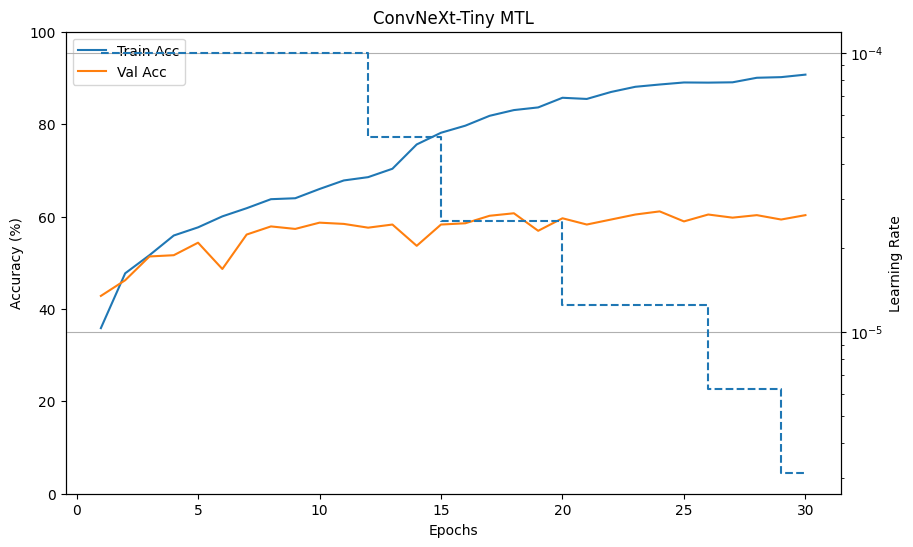


Final Test Accuracy: 67.69%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.3,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=30,
    alpha=0.3
)

plot_history(history, "ConvNeXt-Tiny MTL")

test_accuracy = evaluate_model(model, test_loader)